# 02. Neural Network classification with PyTorch


In [1]:
## 1. Make Classification Data and get it ready

import sklearn
from sklearn.datasets import make_circles


In [2]:
# Make 1000 samples
n_samples = 1000

# Create circles

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(X[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [5]:
print(y[:5])

[1 1 1 1 0]


In [6]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0], 
                        "X2": X[:, 1],
                        "label": y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


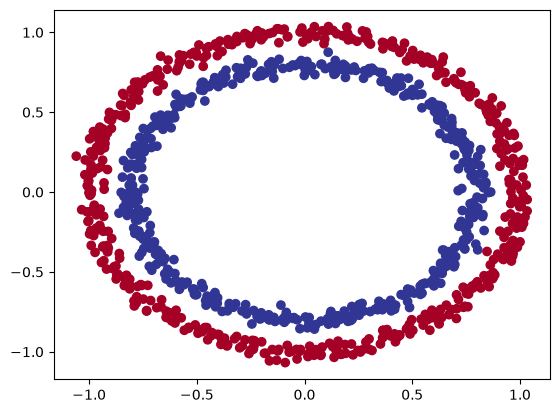

In [7]:
# Visualize, visualize, visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y = X[:,1],
            c=y,
            cmap = plt.cm.RdYlBu);

In [8]:
# Note: The data we're working with is often referred to as a toy dataset

In [9]:
### 1.1 Check input and output shapes
X.shape, y.shape

((1000, 2), (1000,))

In [10]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


In [11]:
#### 1.2 Turn data into tensors and create train and test splits
import torch
torch.__version__

'2.13.0+cu130'

In [12]:
X = torch.from_numpy(X).type(torch.float32)


In [13]:
y = torch.from_numpy(y).type(torch.float32)

In [14]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [15]:
#Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [16]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [17]:
## 2. Building a model

# Classifying a our blue and red dots
# Setup device agnostic code -> construct a model -> define loss function and optimizer -> create training data

In [18]:
from torch import nn

# Made device agnostic code
device =  "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [19]:
# Model creation Subclass nn.Module -> Create 2 nn.linear layers that are capable of handling the shapes of our data -> forward -> instatiate instance and send to target device


In [48]:
# 1. Construct Model Class
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.two_linear_layers =  nn.Sequential(nn.Linear(in_features=2, out_features=5),
                                                nn.Linear(in_features=5, out_features=1))
    def forward(self, x):
        return self.two_linear_layers(x)

model_0 = CircleModelV0().to(device)
model_0


CircleModelV0(
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [21]:
next(model_0.parameters()).device

device(type='cpu')

In [22]:
# Make predictions
untrained_preds = model_0(X_test)
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions: \n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")


Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[ 0.4284],
        [ 0.5335],
        [-0.2676],
        [ 0.6274],
        [-0.9355],
        [-0.8662],
        [-0.0411],
        [-0.3706],
        [-0.2384],
        [ 0.5331]], grad_fn=<SliceBackward0>)

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [23]:
untrained_preds

tensor([[ 4.2842e-01],
        [ 5.3345e-01],
        [-2.6764e-01],
        [ 6.2739e-01],
        [-9.3548e-01],
        [-8.6619e-01],
        [-4.1115e-02],
        [-3.7059e-01],
        [-2.3841e-01],
        [ 5.3312e-01],
        [ 5.3986e-01],
        [ 4.1462e-01],
        [-2.2041e-01],
        [-5.0887e-01],
        [-1.5155e-01],
        [-5.1079e-01],
        [ 2.0421e-01],
        [ 5.4467e-01],
        [ 3.7213e-01],
        [ 3.9165e-01],
        [ 5.5584e-01],
        [-6.9823e-01],
        [ 3.1301e-01],
        [ 5.1498e-01],
        [ 1.7950e-01],
        [-2.0027e-01],
        [-9.2224e-01],
        [-8.9387e-01],
        [-1.2350e-01],
        [-6.0277e-01],
        [-2.5882e-02],
        [ 2.4298e-01],
        [ 5.7332e-01],
        [-8.9039e-01],
        [ 5.9992e-01],
        [ 3.6190e-01],
        [ 5.1054e-01],
        [-4.4172e-01],
        [-8.4580e-01],
        [-5.5978e-01],
        [ 3.0319e-01],
        [-9.5838e-02],
        [ 1.7604e-01],
        [-1

In [24]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.0728,  0.6035],
                      [ 0.1025, -0.5965],
                      [-0.5459,  0.4712],
                      [-0.1717,  0.5802],
                      [ 0.1530, -0.4845]])),
             ('two_linear_layers.0.bias',
              tensor([-0.5225,  0.6700,  0.1789,  0.2432,  0.6132])),
             ('two_linear_layers.1.weight',
              tensor([[ 0.2686, -0.4117,  0.3803,  0.0277, -0.3965]])),
             ('two_linear_layers.1.bias', tensor([0.3593]))])

In [25]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions: \n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[ 0.4284],
        [ 0.5335],
        [-0.2676],
        [ 0.6274],
        [-0.9355],
        [-0.8662],
        [-0.0411],
        [-0.3706],
        [-0.2384],
        [ 0.5331]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [26]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

In [53]:
### 2.1 Setup loss function and optimizer

loss_fn = nn.BCEWithLogitsLoss() # BCEL

optimizer = torch.optim.SGD(params= model_0.parameters(),
                            lr= 0.1)

In [28]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.0728,  0.6035],
                      [ 0.1025, -0.5965],
                      [-0.5459,  0.4712],
                      [-0.1717,  0.5802],
                      [ 0.1530, -0.4845]])),
             ('two_linear_layers.0.bias',
              tensor([-0.5225,  0.6700,  0.1789,  0.2432,  0.6132])),
             ('two_linear_layers.1.weight',
              tensor([[ 0.2686, -0.4117,  0.3803,  0.0277, -0.3965]])),
             ('two_linear_layers.1.bias', tensor([0.3593]))])

In [29]:
# Calculate accuracy -  out of 100 examples, what percentage does our model get right?

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc

In [30]:
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.4284],
        [ 0.5335],
        [-0.2676],
        [ 0.6274],
        [-0.9355]])

In [31]:
## 3.Train model
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6055],
        [0.6303],
        [0.4335],
        [0.6519],
        [0.2818]])

In [32]:
# Use the sigmoid activiation function on our model logits to turn them ino prediction probabilities
y_preds = torch.round(y_pred_probs)

y_preds_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

print(torch.eq(y_preds.squeeze(), y_preds_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([1., 1., 0., 1., 0.])

In [33]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [34]:
X_test, y_test

(tensor([[-3.7519e-01,  6.8266e-01],
         [ 1.5380e-02,  9.6003e-01],
         [-7.0278e-01, -3.1472e-01],
         [-2.8525e-01,  9.6638e-01],
         [ 4.0242e-01, -7.4375e-01],
         [ 6.3228e-01, -5.7111e-01],
         [ 8.5607e-01,  5.4994e-01],
         [ 1.0034e+00,  1.9028e-01],
         [-7.4892e-01, -2.9511e-01],
         [ 5.3780e-02,  9.7388e-01],
         [-4.7020e-01,  7.8749e-01],
         [-2.1686e-01,  7.2418e-01],
         [ 9.7026e-01,  3.6688e-01],
         [-5.8446e-01, -5.7415e-01],
         [-9.1147e-01, -2.4631e-01],
         [ 7.6892e-01, -7.3249e-02],
         [ 3.8408e-01,  6.8299e-01],
         [-6.8364e-01,  7.1417e-01],
         [-5.7777e-01,  5.3652e-01],
         [-8.3274e-01,  4.6625e-01],
         [ 1.2448e-02,  9.8709e-01],
         [ 1.0091e+00, -2.1970e-01],
         [-6.6792e-01,  4.2861e-01],
         [-8.4405e-01,  6.1718e-01],
         [ 6.3680e-01,  7.4591e-01],
         [ 8.9413e-01,  3.6390e-01],
         [-2.3460e-01, -9.6400e-01],
 

In [54]:
### 3.2 Build a train and test loop
torch.manual_seed(42)

EPOCH = 100

X_train, y_train = X_train.to(device), y_train.to(device)

X_test, y_test = X_test.to(device), y_test.to(device)
for epoch in range(EPOCH):

        # Training
        model_0.train()

        # 1. Forward Pass
        y_logits = model_0(X_train).squeeze()
        y_pred = torch.round(torch.sigmoid(y_logits))

        # 2. Calculate Loss    
        loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss expects raw logits as input 
                    y_train)
        acc = accuracy_fn(y_true = y_train,
                        y_pred=y_pred)

        #3 Optimizer zero grad

        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step (gradient descent)
        optimizer.step()

        # Testing
        model_0.eval()

        if epoch % 5:
            with torch.inference_mode():
                # 1. Forward Pass
                test_logits = model_0(X_test).squeeze()
                test_pred = torch.round(torch.sigmoid(test_logits))

                # 2. Calculate test loss/acc
                test_loss = loss_fn(test_logits,
                                    y_test)
                test_acc = accuracy_fn(y_true=y_test,
                                    y_pred=test_pred)
                print(f"Epoch:{epoch} | Loss:{loss:.5f} | Accuracy:{acc:.2f}% | Test Loss:{test_loss:.5f} | Test acc:{test_acc:.2f}%")

Epoch:1 | Loss:0.69326 | Accuracy:50.00% | Test Loss:0.69452 | Test acc:50.00%
Epoch:2 | Loss:0.69325 | Accuracy:50.00% | Test Loss:0.69450 | Test acc:50.00%
Epoch:3 | Loss:0.69324 | Accuracy:50.12% | Test Loss:0.69448 | Test acc:50.00%
Epoch:4 | Loss:0.69322 | Accuracy:50.50% | Test Loss:0.69447 | Test acc:50.50%
Epoch:6 | Loss:0.69320 | Accuracy:53.00% | Test Loss:0.69444 | Test acc:53.50%
Epoch:7 | Loss:0.69319 | Accuracy:55.50% | Test Loss:0.69443 | Test acc:54.00%
Epoch:8 | Loss:0.69318 | Accuracy:57.00% | Test Loss:0.69441 | Test acc:55.00%
Epoch:9 | Loss:0.69317 | Accuracy:58.13% | Test Loss:0.69440 | Test acc:55.50%
Epoch:11 | Loss:0.69315 | Accuracy:59.62% | Test Loss:0.69438 | Test acc:57.50%
Epoch:12 | Loss:0.69314 | Accuracy:59.88% | Test Loss:0.69437 | Test acc:56.50%
Epoch:13 | Loss:0.69313 | Accuracy:58.63% | Test Loss:0.69436 | Test acc:54.50%
Epoch:14 | Loss:0.69312 | Accuracy:57.25% | Test Loss:0.69435 | Test acc:54.00%
Epoch:16 | Loss:0.69311 | Accuracy:55.88% | Test

In [39]:
## 4. Make predictions and evaluate the model -> what's going on?
import requests

from pathlib import Path

# Download helper functions from PyTorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Download helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


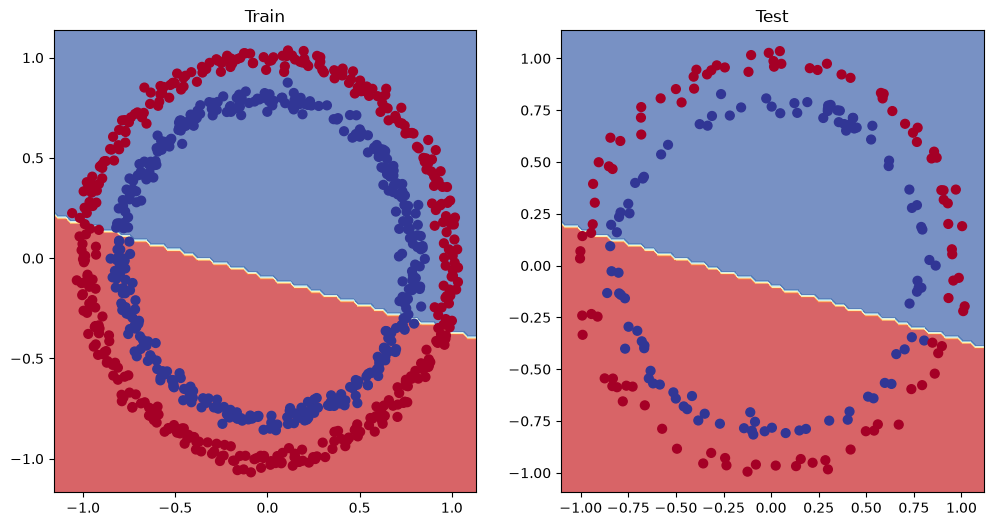

In [55]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test, y_test)

# Improving a model

1. Add more layers - give the model more chances to learn about patterns in the data
2. Add more hidden layers - go from 5 hidden units to 10 hidden units
3. Fit for longer - give the model more chance to learn
4. Changing the activation functions 
5. Change the learning rate 
6. Change the loss function

These options are from the model perspective, can also improve from a data perspective

In [64]:
class CircleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2,
                                 out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10,
                                 out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x))) # this way leverages speed ups where possible behind the scenes
model_1 = CircleModelv1().to(device)
model_1

CircleModelv1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [65]:
# create a loss function
loss_fn = nn.BCEWithLogitsLoss()
#Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.1)
#Write a training loop

epoch = 1000
torch.manual_seed(42)
for e in range(epoch):

    model_1.train()

    # Step 1: Forward Pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) 

    # Step 2: Calculate loss
    loss = loss_fn(y_logits,
                   y_train)
    acc = accuracy_fn(y_train, y_pred)

    # Step 3: zero grad
    optimizer.zero_grad()

    # Step 4: Backpropogation
    loss.backward()

    # Step 5: Step
    optimizer.step()

    model_1.eval()

    #Check results

    if e % 100 == 0:
        with torch.inference_mode():

            #Forward pass for test data
            y_logits_test = model_1(X_test).squeeze()
            y_pred_test = torch.round(torch.sigmoid(y_logits_test)) 

            # Test loss
            test_loss = loss_fn(y_logits_test,y_test)
            test_acc = accuracy_fn(y_test,y_pred_test)
            print(f"Epoch:{epoch} | Loss:{loss:.5f} | Accuracy:{acc:.2f}% | Test Loss:{test_loss:.5f} | Test acc:{test_acc:.2f}%")

            

Epoch:1000 | Loss:0.69396 | Accuracy:50.88% | Test Loss:0.69261 | Test acc:51.00%
Epoch:1000 | Loss:0.69305 | Accuracy:50.38% | Test Loss:0.69379 | Test acc:48.00%
Epoch:1000 | Loss:0.69299 | Accuracy:51.12% | Test Loss:0.69437 | Test acc:46.00%
Epoch:1000 | Loss:0.69298 | Accuracy:51.62% | Test Loss:0.69458 | Test acc:45.00%
Epoch:1000 | Loss:0.69298 | Accuracy:51.12% | Test Loss:0.69465 | Test acc:46.00%
Epoch:1000 | Loss:0.69298 | Accuracy:51.00% | Test Loss:0.69467 | Test acc:46.00%
Epoch:1000 | Loss:0.69298 | Accuracy:51.00% | Test Loss:0.69468 | Test acc:46.00%
Epoch:1000 | Loss:0.69298 | Accuracy:51.00% | Test Loss:0.69468 | Test acc:46.00%
Epoch:1000 | Loss:0.69298 | Accuracy:51.00% | Test Loss:0.69468 | Test acc:46.00%
Epoch:1000 | Loss:0.69298 | Accuracy:51.00% | Test Loss:0.69468 | Test acc:46.00%


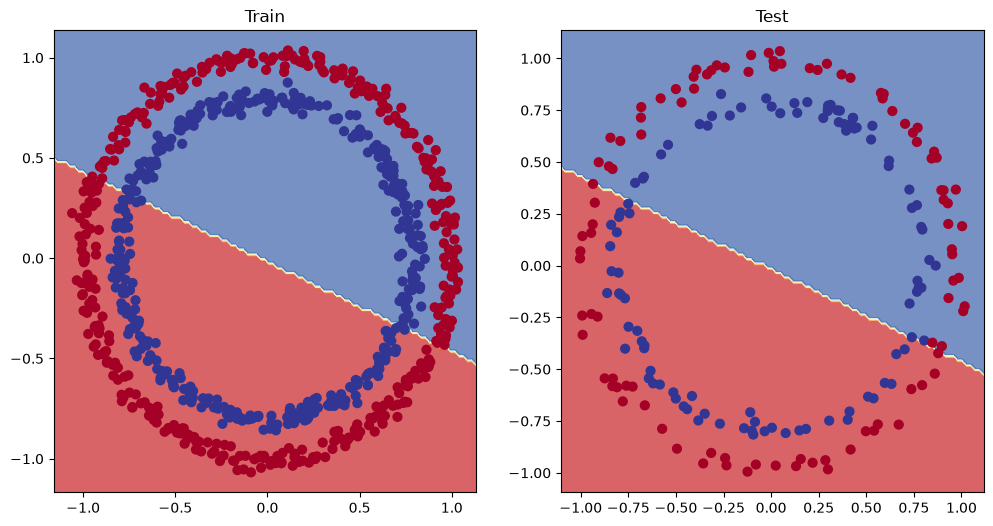

In [68]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test, y_test)

In [ ]:
# Can the model fit a single line
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

#Create data
X_regression = torch.arange()